In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.9 MB/s eta 0:00:00


In [2]:
import cv2

from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Carrega imagem
img = cv2.imread('/content/drive/MyDrive/imagens/pexels_05.jpg', cv2.IMREAD_COLOR_RGB)

# Aplica CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#img_clahe = clahe.apply(img)


array([[[44, 46, 36],
        [44, 46, 36],
        [44, 46, 36],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]],

       [[44, 46, 36],
        [44, 46, 36],
        [44, 46, 36],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]],

       [[44, 46, 36],
        [44, 46, 36],
        [44, 46, 36],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]],

       ...,

       [[34, 36, 26],
        [36, 38, 28],
        [36, 38, 28],
        ...,
        [28, 28, 28],
        [28, 28, 28],
        [28, 28, 28]],

       [[32, 34, 24],
        [34, 36, 26],
        [36, 38, 28],
        ...,
        [28, 28, 28],
        [28, 28, 28],
        [28, 28, 28]],

       [[30, 32, 22],
        [32, 34, 24],
        [36, 38, 28],
        ...,
        [30, 30, 30],
        [30, 30, 30],
        [30, 30, 30]]], dtype=uint8)
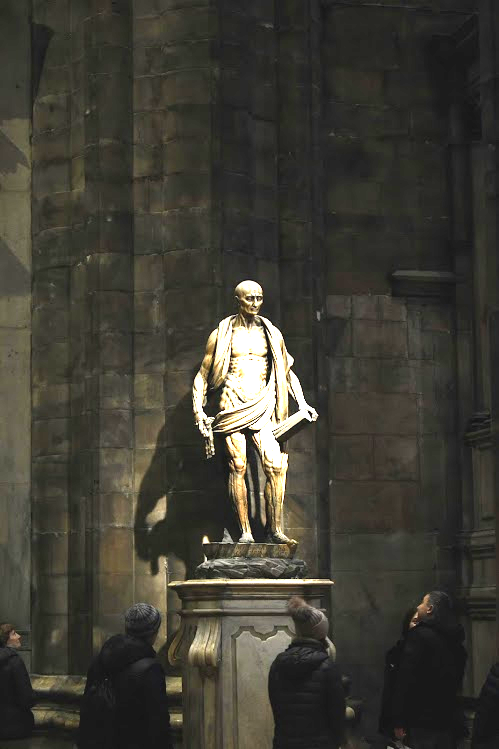

In [4]:
# Alpha = ganho (contraste), Beta = viés (brilho)
img_contrast = cv2.convertScaleAbs(img, alpha=2, beta=20)
save_path = '/content/drive/My Drive/imagens'
os.makedirs(save_path, exist_ok=True)
upscaled = cv2.resize(img_contrast, None, fx=10, fy=10, interpolation=cv2.INTER_LANCZOS4)
denoised = cv2.fastNlMeansDenoisingColored(img_contrast, None, 10, 10, 7, 21)
blur = cv2.blur(img_contrast, (5, 5))
img_gray = cv2.cvtColor(img_contrast, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(img_gray)
output_file = os.path.join(save_path, 'imagem_processada5.jpg')
cv2.imwrite(output_file, img_contrast)
img_contrast


image 1/1 /content/drive/MyDrive/imagens/imagem_processada5.jpg: 640x448 6 persons, 808.3ms
Speed: 14.3ms preprocess, 808.3ms inference, 34.9ms postprocess per image at shape (1, 3, 640, 448)


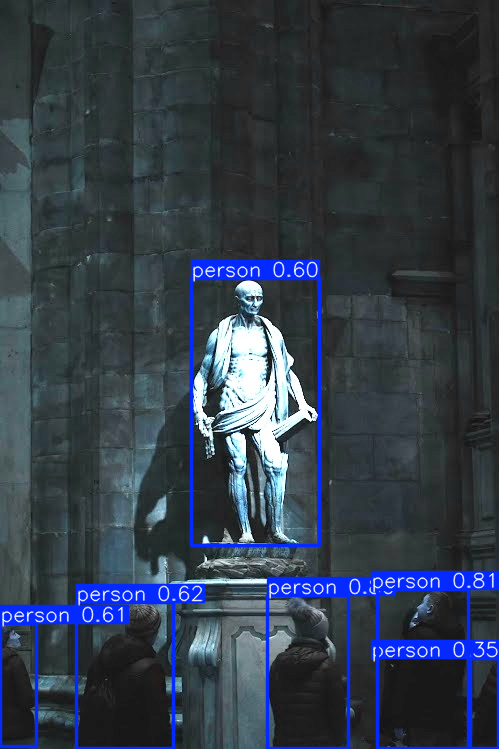

In [5]:
model = YOLO("yolo11s.pt")  # Ou "yolov8n.pt" para mais novo
results = model("/content/drive/MyDrive/imagens/imagem_processada5.jpg")

# Mostrar resultados
results[0].show()